In [3]:
from pybroker import Strategy, StrategyConfig
from pybroker.ext.data import AKShare


def buy_low(ctx):
    # If shares were already purchased and are currently being held, then return.
    if ctx.long_pos():
        return
    # If the latest close price is less than the previous day's low price,
    # then place a buy order.
    if ctx.bars >= 2 and ctx.close[-1] < ctx.low[-2]:
        # Buy a number of shares that is equal to 25% the portfolio.
        ctx.buy_shares = ctx.calc_target_shares(0.25)
        # Set the limit price of the order.
        ctx.buy_limit_price = ctx.close[-1] - 0.01
        # Hold the position for 3 bars before liquidating (in this case, 3 days).
        ctx.hold_bars = 3

data_source = AKShare()
config = StrategyConfig(initial_cash=500_000)
strategy = Strategy(data_source, '6/1/2021', '12/1/2021', config)
strategy.add_execution(buy_low, ['600089.SH', '000520.SZ', '688521.SH'])
result = strategy.backtest()

Backtesting: 2021-06-01 00:00:00 to 2021-12-01 00:00:00

Loading bar data...
Loaded bar data: 0:00:03 

Test split: 2021-06-01 00:00:00 to 2021-12-01 00:00:00


100% (124 of 124) |######################| Elapsed Time: 0:00:00 Time:  0:00:00



Finished backtest: 0:00:07


In [4]:
result

TestResult(start_date=datetime.datetime(2021, 6, 1, 0, 0), end_date=datetime.datetime(2021, 12, 1, 0, 0), portfolio=                 cash     equity  margin  market_value       pnl  \
date                                                               
2021-06-01  500000.00  500000.00     0.0     500000.00      0.00   
2021-06-02  500000.00  500000.00     0.0     500000.00      0.00   
2021-06-03  500000.00  500000.00     0.0     500000.00      0.00   
2021-06-04  500000.00  500000.00     0.0     500000.00      0.00   
2021-06-07  500000.00  500000.00     0.0     500000.00      0.00   
...               ...        ...     ...           ...       ...   
2021-11-25  512989.16  512989.16     0.0     512989.16  12989.16   
2021-11-26  512989.16  512989.16     0.0     512989.16  12989.16   
2021-11-29  512989.16  512989.16     0.0     512989.16  12989.16   
2021-11-30  512989.16  512989.16     0.0     512989.16  12989.16   
2021-12-01  512989.16  512989.16     0.0     512989.16  12989.16   


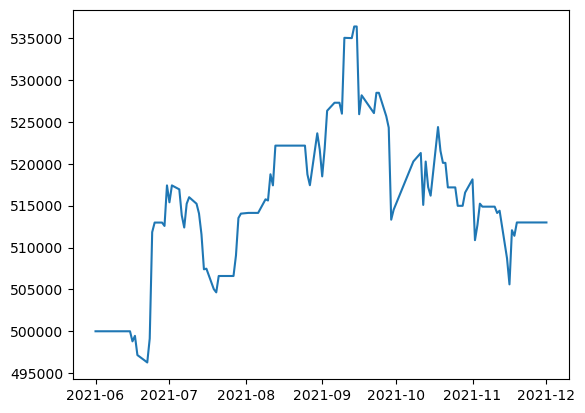

In [5]:
import matplotlib.pyplot as plt

chart = plt.subplot2grid((3, 2), (0, 0), rowspan=3, colspan=2)
chart.plot(result.portfolio.index, result.portfolio['market_value'])